# 📊 Đánh giá Iterative Graph RAG - Level 1 (1-hop Questions)

Notebook này đánh giá hiệu suất của mô hình Iterative Graph RAG trên bộ dữ liệu câu hỏi trắc nghiệm Level 1.

**Các chỉ số đánh giá:**
- **Accuracy**: Tỷ lệ câu trả lời đúng
- **Precision**: Tỷ lệ dự đoán đúng trong số các dự đoán positive
- **Recall**: Tỷ lệ phát hiện đúng trong số các ground truth positive
- **F1-Score**: Trung bình điều hòa của Precision và Recall

**Dataset**: `eval_level1_875.csv` - Câu hỏi trắc nghiệm A/B về quan hệ 1-hop trong đồ thị

## 1. Import Libraries và Cấu hình

In [ ]:
import pandas as pd
import numpy as np
import sys
import re
import os
import time
from itertools import combinations
from tqdm import tqdm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ML Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

# NLP & Graph
from rapidfuzz import process, fuzz
from neo4j import GraphDatabase
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
from langchain_huggingface import HuggingFacePipeline

# --- CẤU HÌNH ---
NEO4J_URI = "neo4j://localhost:7687"
NEO4J_USER = "neo4j"
NEO4J_PASSWORD = "123456789"
MODEL_ID = "Qwen/Qwen3-0.6B"
MAX_ITERATIONS = 3  # Giảm xuống để đánh giá nhanh hơn

# File paths
INPUT_CSV = "eval_level1_875.csv"
OUTPUT_CSV = "eval_level1_results.csv"
CHECKPOINT_CSV = "eval_iterative_checkpoint.csv"  # File lưu tiến trình

# Sampling (đặt None để chạy toàn bộ)
SAMPLE_SIZE = None  # None = chạy toàn bộ dataset
START_INDEX = 0     # Bắt đầu từ index nào (tự động skip nếu có checkpoint)

print("✅ Import thành công!")
print(f"📌 Model: {MODEL_ID}")
print(f"📌 Dataset: {INPUT_CSV}")
print(f"📌 Checkpoint: {CHECKPOINT_CSV}")

✅ Import thành công!


## 2. Khởi tạo Hệ thống (LLM + Neo4j)

In [31]:
def init_system():
    """Khởi tạo LLM, tokenizer, Neo4j driver và danh sách thực thể"""
    print("⏳ Đang khởi tạo hệ thống...")
    
    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
    model = AutoModelForCausalLM.from_pretrained(MODEL_ID, torch_dtype="auto", device_map="auto")
    
    # Temperature thấp để đánh giá chính xác hơn
    pipe = pipeline(
        "text-generation", model=model, tokenizer=tokenizer,
        max_new_tokens=32768, temperature=0.3, top_p=0.95, top_k=20, 
        repetition_penalty=1.1,
    )
    llm = HuggingFacePipeline(pipeline=pipe)
    driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))
    
    # Load entity names for normalization
    print("⏳ Đang tải danh sách thực thể từ Neo4j...")
    all_names = []
    try:
        with driver.session() as session:
            result = session.run("MATCH (n) WHERE n.name IS NOT NULL RETURN DISTINCT n.name as name")
            all_names = [r["name"] for r in result]
        print(f"✅ Đã tải {len(all_names)} tên thực thể.")
    except Exception as e:
        print(f"⚠️ Lỗi: {e}")

    print("✅ Hệ thống sẵn sàng!")
    return llm, tokenizer, driver, all_names

# Khởi tạo
llm, tokenizer, driver, all_names = init_system()

⏳ Đang khởi tạo hệ thống...


Device set to use cuda:0


⏳ Đang tải danh sách thực thể từ Neo4j...
✅ Đã tải 5787 tên thực thể.
✅ Hệ thống sẵn sàng!


## 3. Định nghĩa các hàm trích xuất thực thể và xử lý

In [32]:
def parse_qwen3_output(text):
    """Loại bỏ phần thinking của Qwen3"""
    if "<think>" in text: 
        text = text.split("</think>")[-1]
    return text.strip()

def clean_entities(raw_text, source_text):
    """Làm sạch danh sách thực thể trích xuất"""
    candidates = [e.strip() for e in raw_text.split(',') if e.strip()]
    candidates = [e.replace(".", "").replace('"', '').replace("'", "") for e in candidates]
    valid = [c for c in candidates if len(c) > 2]
    return valid

def normalize_entities(entities, all_names, threshold=85):
    """Chuẩn hóa tên thực thể bằng RapidFuzz"""
    if not all_names: 
        return entities
    
    normalized = []
    for entity in entities:
        match = process.extractOne(entity, all_names, scorer=fuzz.WRatio)
        if match:
            best_name, score, _ = match
            if score >= threshold:
                normalized.append(best_name)
            # Loại bỏ nếu điểm thấp
    return list(set(normalized))

def extract_initial_entities(question):
    """Vòng 1: Trích xuất thực thể từ câu hỏi gốc"""
    examples = """
    Hỏi: Ai là đạo diễn phim Titanic? câu hỏi này có 1 thực thể -> Thực thể: Titanic
    Hỏi: Jon Voight là ai và có quan hệ gì với Angelina Jolie? câu hỏi này có 2 thực thể-> Thực thể: Jon Voight, Angelina Jolie
    Hỏi: Brad Pitt và Leonardo DiCaprio có đóng chung phim Titanic không? câu hỏi này có 3 thực thể -> Thực thể: Brad Pitt, Leonardo DiCaprio, Titanic
    """
    messages = [
        {"role": "system", "content": "Trích xuất các TÊN RIÊNG (Người, Phim) từ câu hỏi (có thể 1, 2 hoặc có lớn hơn 2 thực thể (3,4,5,6, ..)). Ngăn cách bởi dấu phẩy. Không thêm từ thừa."},
        {"role": "user", "content": f"Đây là các ví dụ{examples}\n. Đây là câu hỏi cần trích xuất: {question}\nThực thể:"}
    ]
    
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True, enable_thinking=True)
    res = llm.invoke(prompt)
    if prompt in res: 
        res = res.replace(prompt, "")
    
    raw = parse_qwen3_output(res).split('\n')[0].replace("Thực thể:", "").strip()
    return clean_entities(raw, question)

def extract_more_entities(question, current_context):
    """Vòng >1: Trích xuất thêm thực thể từ ngữ cảnh đã tìm được"""
    system_msg = """Bạn là trợ lý suy luận. 
    Dựa vào CÂU HỎI và THÔNG TIN ĐÃ BIẾT, hãy xác định xem cần tìm kiếm thêm thông tin về NHÂN VẬT hoặc BỘ PHIM nào nữa để trả lời trọn vẹn câu hỏi.
    Chỉ liệt kê tên riêng mới. Nếu không cần thêm ai, trả về 'NONE'."""
    
    user_msg = f"""CÂU HỎI: {question}
    THÔNG TIN ĐÃ BIẾT:
    {current_context}
    
    Cần tìm thêm thông tin về ai (Tên riêng)?"""
    
    messages = [{"role": "system", "content": system_msg}, {"role": "user", "content": user_msg}]
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True, enable_thinking=True)
    res = llm.invoke(prompt)
    if prompt in res: 
        res = res.replace(prompt, "")
    
    raw = parse_qwen3_output(res)
    
    # Nếu model nói NONE hoặc không tìm thấy gì
    if "NONE" in raw or "không cần" in raw.lower():
        return []
    
    return clean_entities(raw, raw)

def check_sufficiency(question, context):
    """Kiểm tra xem thông tin đã đủ để trả lời chưa - giống 4_iterative_graph_rag.py"""
    if not context: 
        return False, "Chưa có thông tin."
    
    messages = [
        {"role": "system", "content": "Bạn là giám khảo khắt khe. Nhiệm vụ: Đánh giá xem thông tin được cung cấp đã ĐỦ để trả lời chính xác câu hỏi chưa. Chỉ trả lời 'ĐỦ' hoặc 'CHƯA ĐỦ'."},
        {"role": "user", "content": f"CÂU HỎI: {question}\nTHÔNG TIN:\n{context}\n\nĐánh giá:"}
    ]
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    res = llm.invoke(prompt)
    if prompt in res: 
        res = res.replace(prompt, "")
    
    answer = parse_qwen3_output(res).lower()
    is_sufficient = "đủ" in answer and "chưa" not in answer
    return is_sufficient, answer

print("✅ Định nghĩa các hàm trích xuất thực thể và kiểm tra độ đầy đủ thành công!")

✅ Định nghĩa các hàm trích xuất thực thể và kiểm tra độ đầy đủ thành công!


## 4. Định nghĩa các hàm truy vấn đồ thị Neo4j

In [33]:
def find_node_qid(session, name):
    """Tìm QID của node theo tên (fuzzy search)"""
    result = session.run(
        "CALL db.index.fulltext.queryNodes('names', $name + '~') YIELD node, score "
        "RETURN node.name, node.qid, labels(node) ORDER BY score DESC LIMIT 1", 
        name=name
    ).single()
    if result: 
        return {"name": result[0], "qid": result[1], "labels": result[2]}
    return None

def get_node_details_text(session, qid, name):
    """Lấy thông tin chi tiết của node"""
    node = session.run("MATCH (n {qid: $qid}) RETURN n.gender, n.birthDate", qid=qid).single()
    if not node: 
        return ""
    info = [f"**{name}:**"]
    if node[0]: 
        info.append(f"Giới tính: {node[0]}")
    if node[1]: 
        info.append(f"Sinh: {str(node[1]).split('T')[0]}")
    return " - ".join(info)

def get_relationship_action(rel_type, is_forward):
    """Map relationship type to Vietnamese text"""
    mapping = {
        "ACTED_IN": ("đóng trong phim", "có diễn viên là"),
        "DIRECTED": ("là đạo diễn của", "được đạo diễn bởi"),
        "PRODUCED": ("sản xuất phim", "được sản xuất bởi"),
        "IS_CHILD_OF": ("là con của", "là cha/mẹ của"),
        "IS_CHILD_OF_DAD": ("là con của cha", "là cha của"),
        "IS_CHILD_OF_MOM": ("là con của mẹ", "là mẹ của"),
        "IS_PARENT_OF": ("là cha/mẹ của", "là con của"),
        "IS_SPOUSE_OF": ("là vợ/chồng của", "là vợ/chồng của"),
        "IS_PARTNER_OF": ("là bạn đời của", "là bạn đời của"),
        "IS_SIBLING_OF": ("là anh/chị em với", "là anh/chị em với"),
        "HAS_GRANDPARENT_OF": ("là cháu của", "là ông/bà của"),
    }
    if rel_type in mapping:
        return mapping[rel_type][0 if is_forward else 1]
    return f"có quan hệ {rel_type} với"

def format_path_text(path):
    """Format đường đi ngữ nghĩa"""
    nodes = path.nodes
    rels = path.relationships
    parts = []
    
    for i, rel in enumerate(rels):
        start = nodes[i]
        end = nodes[i+1]
        is_forward = (rel.start_node.element_id == start.element_id)
        action = get_relationship_action(rel.type, is_forward)
        parts.append(f"{start['name']} {action} {end['name']}")
        
    return " -> ".join(parts) + "."

def get_full_graph_context(entity_names):
    """Truy xuất context đầy đủ từ đồ thị (Full Mesh) - giống 4_iterative_graph_rag.py"""
    with driver.session() as session:
        nodes = []
        for name in entity_names:
            n = find_node_qid(session, name)
            if n: 
                nodes.append(n)
        
        if not nodes: 
            return "Không tìm thấy node nào."
        
        context_parts = []
        
        # 1. Thông tin chi tiết
        context_parts.append("--- THÔNG TIN CÁ NHÂN ---")
        for n in nodes:
            context_parts.append(get_node_details_text(session, n['qid'], n['name']))
            
        # 2. Quan hệ (Full Mesh)
        context_parts.append("\n--- MỐI QUAN HỆ ---")
        
        # PHẦN 1: Lấy các mối quan hệ trực tiếp (1-hop) cho TỪNG node
        for n in nodes:
            res = session.run(
                "MATCH (n {qid: $id})-[r]-(m) RETURN r, n, m LIMIT 50", 
                id=n['qid']
            )
            
            has_rel = False
            for record in res:
                r = record['r']
                n_node = record['n']
                m_node = record['m']
                
                is_forward = (r.start_node.element_id == n_node.element_id)
                action = get_relationship_action(r.type, is_forward)
                context_parts.append(f"{n_node['name']} {action} {m_node['name']}")
                has_rel = True
            
            if not has_rel:
                context_parts.append(f"{n['name']} không có quan hệ nào trong DB.")

        # PHẦN 2: Nếu có >= 2 Node -> Tìm đường giữa TẤT CẢ CÁC CẶP (All Pairs)
        if len(nodes) >= 2:
            context_parts.append("\n--- LIÊN KẾT GIỮA CÁC THỰC THỂ ---")
            pairs = list(combinations(nodes, 2))
            
            for start, end in pairs:
                query = """
                    MATCH (p1 {qid: $s}), (p2 {qid: $e})
                    MATCH path = shortestPath((p1)-[*..6]-(p2))
                    RETURN path
                """
                result = session.run(query, s=start['qid'], e=end['qid']).single()
                
                if result:
                    path_text = format_path_text(result['path'])
                    context_parts.append(f"- Quan hệ giữa {start['name']} và {end['name']}: {path_text}")
                else:
                    context_parts.append(f"- Không tìm thấy liên kết trực tiếp giữa {start['name']} và {end['name']}.")
                    
        return "\n".join(context_parts)

print("✅ Định nghĩa hàm truy vấn đồ thị (Full Mesh) thành công!")

✅ Định nghĩa hàm truy vấn đồ thị (Full Mesh) thành công!


## 5. Định nghĩa hàm trả lời câu hỏi và đánh giá

In [34]:
def generate_final_answer(question, context, option_a, option_b):
    """
    Sinh câu trả lời cuối cùng từ LLM dựa trên context.
    Yêu cầu trả lời theo format chuẩn để dễ đánh giá.
    """
    system_prompt = """Bạn là chuyên gia về điện ảnh và người nổi tiếng. 
Dựa vào DỮ LIỆU được cung cấp, hãy trả lời câu hỏi trắc nghiệm.
Trả lời theo format: "Đáp án: [A/B] - [Tên đáp án]. Lý do: [giải thích ngắn]"
"""
    
    user_prompt = f"""DỮ LIỆU:
{context}

CÂU HỎI: {question}

A) {option_a}
B) {option_b}

Hãy chọn đáp án đúng (A hoặc B) dựa trên dữ liệu trên."""

    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt}
    ]
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True, enable_thinking=True)
    res = llm.invoke(prompt)
    if prompt in res: 
        res = res.replace(prompt, "")
    return parse_qwen3_output(res)

def solve_question_iterative(question, option_a, option_b):
    """
    Pipeline ITERATIVE hoàn chỉnh - giống 4_iterative_graph_rag.py
    
    Vòng lặp:
    1. Trích xuất thực thể
    2. Chuẩn hóa thực thể
    3. Truy vấn đồ thị
    4. Kiểm tra độ đầy đủ
    5. Nếu chưa đủ -> Trích xuất thêm thực thể từ context
    6. Lặp lại cho đến khi đủ hoặc hết vòng lặp
    """
    accumulated_entities = set()
    current_context = ""
    
    for i in range(MAX_ITERATIONS):
        # BƯỚC 1: TRÍCH XUẤT
        new_entities = []
        if i == 0:
            # Vòng 1: Lấy từ câu hỏi
            new_entities = extract_initial_entities(question)
        else:
            # Vòng > 1: Lấy từ ngữ cảnh cũ (Suy luận)
            new_entities = extract_more_entities(question, current_context)
        
        # BƯỚC 2: CHUẨN HÓA
        new_entities = normalize_entities(new_entities, all_names)
        
        # Cập nhật danh sách thực thể
        prev_len = len(accumulated_entities)
        for e in new_entities:
            accumulated_entities.add(e)
        
        # Nếu không tìm thêm được thực thể mới -> Dừng
        if len(accumulated_entities) == prev_len and i > 0:
            break
            
        if not accumulated_entities:
            return "Không tìm thấy thực thể", ""
            
        # BƯỚC 3: TRUY XUẤT GRAPH
        current_context = get_full_graph_context(list(accumulated_entities))
        
        # BƯỚC 4: KIỂM TRA ĐỘ ĐẦY ĐỦ
        is_enough, _ = check_sufficiency(question, current_context)
        
        if is_enough:
            break
    
    # BƯỚC 5: SINH CÂU TRẢ LỜI (với format chuẩn MCQ)
    answer = generate_final_answer(question, current_context, option_a, option_b)
    
    return answer, current_context

def evaluate_answer(bot_answer, ground_truth, option_a, option_b):
    """
    Đánh giá câu trả lời của bot với ground_truth
    
    Logic:
    - ground_truth là TÊN ĐÚNG (ví dụ: "Elle Macpherson")
    - Kiểm tra xem bot_answer có chứa ground_truth không
    - Dùng rapidfuzz để xử lý trường hợp tên gần giống
    
    Returns: 1 nếu đúng, 0 nếu sai
    """
    bot_ans_lower = bot_answer.lower()
    gt_lower = ground_truth.lower()
    opt_a_lower = option_a.lower()
    opt_b_lower = option_b.lower()
    
    # Check 1: Bot trả lời chứa ground_truth (exact match)
    if gt_lower in bot_ans_lower:
        return 1
    
    # Check 2: Dùng fuzzy matching với ngưỡng cao
    score = fuzz.partial_ratio(gt_lower, bot_ans_lower)
    if score >= 85:
        return 1
    
    # Check 3: Bot chọn đáp án sai (chứa option còn lại)
    wrong_option = opt_a_lower if gt_lower == opt_b_lower else opt_b_lower
    
    # Nếu bot chứa đáp án sai VÀ không chứa đáp án đúng -> Sai
    if wrong_option in bot_ans_lower and gt_lower not in bot_ans_lower:
        return 0
    
    # Check 4: Bot trả lời A/B trực tiếp (format chuẩn)
    correct_letter = "a" if gt_lower == opt_a_lower else "b"
    wrong_letter = "b" if correct_letter == "a" else "a"
    
    # Kiểm tra các pattern phổ biến cho đáp án đúng
    correct_patterns = [
        f"đáp án: {correct_letter}",
        f"đáp án {correct_letter}",
        f"chọn {correct_letter}",
        f"là {correct_letter})",
        f"là {correct_letter}.",
        f"→ {correct_letter}",
    ]
    
    # Kiểm tra các pattern cho đáp án sai
    wrong_patterns = [
        f"đáp án: {wrong_letter}",
        f"đáp án {wrong_letter}",
        f"chọn {wrong_letter}",
        f"là {wrong_letter})",
        f"là {wrong_letter}.",
        f"→ {wrong_letter}",
    ]
    
    for pattern in correct_patterns:
        if pattern in bot_ans_lower:
            return 1
    
    for pattern in wrong_patterns:
        if pattern in bot_ans_lower:
            return 0
    
    # Default: Không match được -> Sai
    return 0

print("✅ Định nghĩa hàm solve_question_iterative (VÒNG LẶP SUY LUẬN) với FORMAT CHUẨN MCQ thành công!")

✅ Định nghĩa hàm solve_question_iterative (VÒNG LẶP SUY LUẬN) với FORMAT CHUẨN MCQ thành công!


## 6. Load Dataset và Chạy Đánh giá

In [35]:
# Load dataset
df = pd.read_csv(INPUT_CSV)
print(f"📊 Đã tải {len(df)} câu hỏi từ {INPUT_CSV}")
print(f"\n📋 Phân bố theo loại quan hệ:")
print(df['rel_type'].value_counts())

# Preview
df.head()

📊 Đã tải 808 câu hỏi từ eval_level1_875.csv

📋 Phân bố theo loại quan hệ:
rel_type
IS_PARTNER_OF         100
IS_PARENT_OF          100
ACTED_IN              100
PRODUCED              100
IS_SPOUSE_OF          100
HAS_GRANDPARENT_OF    100
DIRECTED              100
IS_SIBLING_OF         100
IS_CHILD_OF_DAD         6
IS_CHILD_OF_MOM         2
Name: count, dtype: int64


,level,rel_type,question,option_a,option_b,answer,ground_truth
0,1,IS_PARTNER_OF,Bạn đời của Kevin Costner là ai?,Vanessa Hudgens,Elle Macpherson,B,Elle Macpherson
1,1,IS_PARTNER_OF,Bạn đời của George Clooney là ai?,Kelly Preston,Kidada Jones,A,Kelly Preston
2,1,IS_PARENT_OF,Ai là con của Tom Hanks?,E. A. Hanks,Grace Cummings,A,E. A. Hanks
3,1,ACTED_IN,Ai đã tham gia vào bộ phim 'Sabotage'?,Connie Britton,Terrence Howard,B,Terrence Howard
4,1,IS_PARENT_OF,Ai là con của Robert De Niro?,Drena De Niro,Austin Jack Lynch,A,Drena De Niro


In [ ]:
# Lấy dữ liệu TUẦN TỰ (không random) để dễ resume
if SAMPLE_SIZE:
    df_eval = df.iloc[START_INDEX:START_INDEX + SAMPLE_SIZE].reset_index(drop=True)
    print(f"⚠️ Chạy trên {len(df_eval)} câu hỏi (từ index {START_INDEX} đến {START_INDEX + SAMPLE_SIZE - 1})")
else:
    df_eval = df.iloc[START_INDEX:].reset_index(drop=True)
    print(f"🚀 Chạy đánh giá trên {len(df_eval)} câu hỏi (từ index {START_INDEX})")

# AUTO RESUME: Tự động tiếp tục từ checkpoint nếu có
if os.path.exists(CHECKPOINT_CSV):
    checkpoint_df = pd.read_csv(CHECKPOINT_CSV)
    print(f"\n💾 Tìm thấy checkpoint với {len(checkpoint_df)} kết quả đã lưu")
    print("🔄 Tự động tiếp tục từ checkpoint...")
    resume = True
else:
    checkpoint_df = None
    resume = False
    print("\n🆕 Bắt đầu mới từ đầu...")

⚠️ Chạy thử trên 10 câu hỏi

🔄 Bắt đầu đánh giá...


In [ ]:
# === HOÀN TOÀN TỰ ĐỘNG - KHÔNG CẦN CAN THIỆP ===

# Khởi tạo hoặc load từ checkpoint
if resume and checkpoint_df is not None:
    results = checkpoint_df.to_dict('records')
    start_idx = len(results)
    print(f"📂 Tự động resume từ câu hỏi thứ {start_idx + 1}/{len(df_eval)}")
else:
    results = []
    start_idx = 0

# Cho metrics
y_true = [1] * start_idx  # Ground truth đã có
y_pred = [r['score'] for r in results] if results else []

# Thời gian bắt đầu
start_time = time.time()
CHECKPOINT_INTERVAL = 10  # Lưu checkpoint sau mỗi 10 câu

print(f"\n{'='*60}")
print(f"🚀 BẮT ĐẦU ĐÁNH GIÁ ITERATIVE GRAPH RAG")
print(f"{'='*60}")
print(f"📋 Từ câu {start_idx + 1} đến câu {len(df_eval)}")
print(f"📋 Checkpoint tự động lưu sau mỗi {CHECKPOINT_INTERVAL} câu")
print(f"{'='*60}\n")

# === VÒNG LẶP ĐÁNH GIÁ CHÍNH (SỬ DỤNG ITERATIVE RAG) ===
for idx in tqdm(range(start_idx, len(df_eval)), desc="Đánh giá Iterative RAG", initial=start_idx, total=len(df_eval)):
    row = df_eval.iloc[idx]
    question = row['question']
    ground_truth = row['ground_truth']
    option_a = row['option_a']
    option_b = row['option_b']
    rel_type = row['rel_type']
    
    try:
        # Chạy pipeline ITERATIVE (có vòng lặp suy luận) - truyền thêm options để format MCQ
        bot_answer, context = solve_question_iterative(question, option_a, option_b)
        
        # Đánh giá
        score = evaluate_answer(bot_answer, ground_truth, option_a, option_b)
        
    except Exception as e:
        bot_answer = f"Error: {str(e)}"
        context = ""
        score = 0
        print(f"\n❌ Lỗi câu {idx + 1}: {e}")
    
    # Lưu kết quả
    results.append({
        "question": question,
        "option_a": option_a,
        "option_b": option_b,
        "ground_truth": ground_truth,
        "bot_answer": bot_answer[:500] if bot_answer else "",
        "rel_type": rel_type,
        "score": score,
        "context_length": len(context) if context else 0
    })
    
    # Cho metrics
    y_true.append(1)  # Ground truth luôn là 1 (có đáp án đúng)
    y_pred.append(score)
    
    # Lưu checkpoint định kỳ
    if (idx + 1) % CHECKPOINT_INTERVAL == 0:
        pd.DataFrame(results).to_csv(CHECKPOINT_CSV, index=False, encoding='utf-8-sig')
        correct_so_far = sum(r['score'] for r in results)
        acc_so_far = correct_so_far / len(results) * 100
        elapsed = time.time() - start_time
        print(f"\n💾 Checkpoint: {len(results)} câu | Accuracy: {acc_so_far:.1f}% | Time: {elapsed/60:.1f}m")

# Lưu checkpoint cuối cùng
pd.DataFrame(results).to_csv(CHECKPOINT_CSV, index=False, encoding='utf-8-sig')

# Tổng kết
total_time = time.time() - start_time
print(f"\n{'='*60}")
print(f"🎉 HOÀN THÀNH ĐÁNH GIÁ!")
print(f"{'='*60}")
print(f"✅ Tổng số câu: {len(results)}")
print(f"⏱️ Tổng thời gian: {total_time/60:.1f} phút ({total_time/3600:.2f} giờ)")
print(f"💾 Đã lưu vào: {CHECKPOINT_CSV}")

Đánh giá:   0%|          | 0/10 [00:00<?, ?it/s]

Đánh giá: 100%|██████████| 10/10 [02:01<00:00, 12.12s/it]


✅ Hoàn thành đánh giá 10 câu hỏi với Iterative RAG (FORMAT MCQ CHUẨN)!


## 7. Tính toán và Hiển thị Metrics

In [38]:
# Chuyển kết quả sang DataFrame
results_df = pd.DataFrame(results)

# === TÍNH TOÁN METRICS ===
total = len(results_df)
correct = results_df['score'].sum()

# Accuracy
accuracy = accuracy_score(y_true, y_pred)

# Precision, Recall, F1 (binary)
# Ở đây: positive class = 1 (trả lời đúng)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)

# === HIỂN THỊ KẾT QUẢ ===
print("=" * 60)
print("📊 KẾT QUẢ ĐÁNH GIÁ ITERATIVE GRAPH RAG - LEVEL 1")
print("=" * 60)
print(f"📁 Dataset: {INPUT_CSV}")
print(f"📝 Tổng số câu hỏi: {total}")
print(f"✅ Số câu đúng: {correct}")
print(f"❌ Số câu sai: {total - correct}")
print("-" * 60)
print(f"🎯 ACCURACY:  {accuracy * 100:.2f}%")
print(f"📐 PRECISION: {precision * 100:.2f}%")
print(f"📏 RECALL:    {recall * 100:.2f}%")
print(f"⚖️  F1-SCORE:  {f1 * 100:.2f}%")
print("=" * 60)

# Tạo summary DataFrame
metrics_summary = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Value': [f"{accuracy*100:.2f}%", f"{precision*100:.2f}%", f"{recall*100:.2f}%", f"{f1*100:.2f}%"]
})
metrics_summary

📊 KẾT QUẢ ĐÁNH GIÁ ITERATIVE GRAPH RAG - LEVEL 1
📁 Dataset: eval_level1_875.csv
📝 Tổng số câu hỏi: 10
✅ Số câu đúng: 8
❌ Số câu sai: 2
------------------------------------------------------------
🎯 ACCURACY:  80.00%
📐 PRECISION: 100.00%
📏 RECALL:    80.00%
⚖️  F1-SCORE:  88.89%


,Metric,Value
0,Accuracy,80.00%
1,Precision,100.00%
2,Recall,80.00%
3,F1-Score,88.89%


## 8. Phân tích theo Loại Quan hệ (Relationship Type)

In [39]:
# Tính accuracy theo từng loại quan hệ
rel_stats = results_df.groupby('rel_type').agg({
    'score': ['sum', 'count', 'mean']
}).round(4)
rel_stats.columns = ['Correct', 'Total', 'Accuracy']
rel_stats['Accuracy'] = (rel_stats['Accuracy'] * 100).round(2)
rel_stats = rel_stats.sort_values('Accuracy', ascending=False)

print("📊 ACCURACY THEO LOẠI QUAN HỆ:")
print("-" * 50)
rel_stats

📊 ACCURACY THEO LOẠI QUAN HỆ:
--------------------------------------------------


,Correct,Total,Accuracy
rel_type,,,
DIRECTED,2,2,100.0
HAS_GRANDPARENT_OF,2,2,100.0
IS_PARENT_OF,2,2,100.0
IS_SIBLING_OF,1,1,100.0
IS_PARTNER_OF,1,1,100.0
ACTED_IN,0,1,0.0
PRODUCED,0,1,0.0


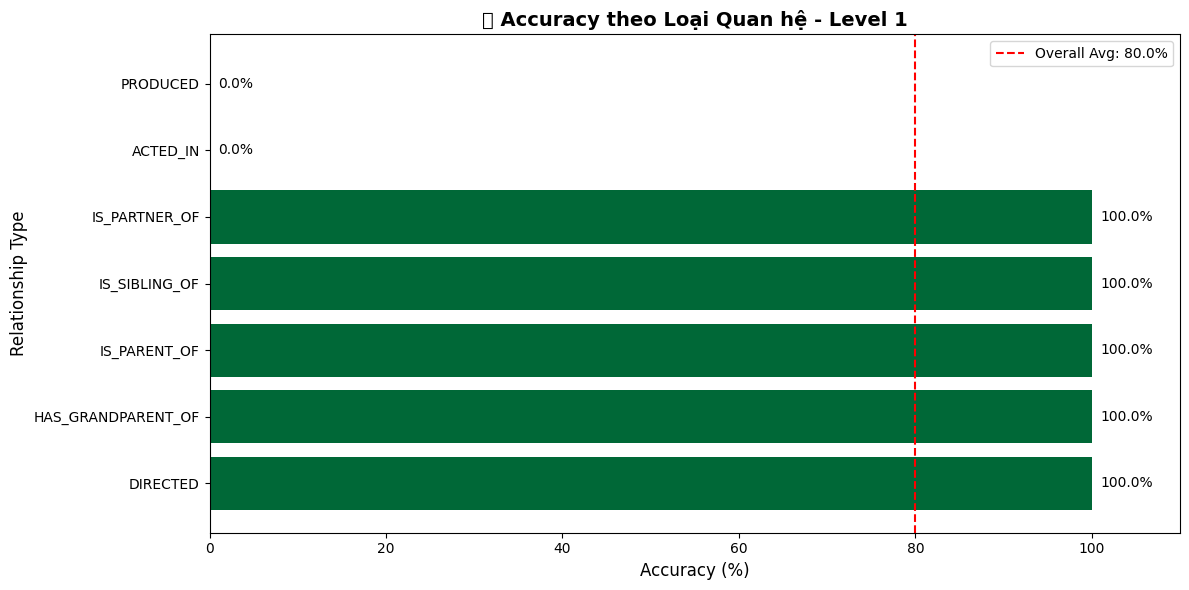

In [40]:
# Vẽ biểu đồ Accuracy theo loại quan hệ
fig, ax = plt.subplots(figsize=(12, 6))

colors = plt.cm.RdYlGn(rel_stats['Accuracy'] / 100)
bars = ax.barh(rel_stats.index, rel_stats['Accuracy'], color=colors)

# Thêm label trên mỗi bar
for bar, acc in zip(bars, rel_stats['Accuracy']):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
            f'{acc:.1f}%', va='center', fontsize=10)

ax.set_xlabel('Accuracy (%)', fontsize=12)
ax.set_ylabel('Relationship Type', fontsize=12)
ax.set_title('📊 Accuracy theo Loại Quan hệ - Level 1', fontsize=14, fontweight='bold')
ax.set_xlim(0, 110)
ax.axvline(x=accuracy*100, color='red', linestyle='--', label=f'Overall Avg: {accuracy*100:.1f}%')
ax.legend()

plt.tight_layout()
plt.show()

## 9. Lưu kết quả và Phân tích Lỗi

In [41]:
# Lưu kết quả chi tiết
results_df.to_csv(OUTPUT_CSV, index=False, encoding='utf-8-sig')
print(f"💾 Đã lưu kết quả chi tiết vào: {OUTPUT_CSV}")

# Lưu metrics summary
metrics_full = {
    'metric': ['accuracy', 'precision', 'recall', 'f1_score', 'total_questions', 'correct_answers'],
    'value': [accuracy, precision, recall, f1, total, correct]
}
pd.DataFrame(metrics_full).to_csv('eval_level1_metrics.csv', index=False)
print("💾 Đã lưu metrics vào: eval_level1_metrics.csv")

💾 Đã lưu kết quả chi tiết vào: eval_level1_results.csv
💾 Đã lưu metrics vào: eval_level1_metrics.csv


In [42]:
# Xem một số câu đúng
print("✅ MẪU CÂU TRẢ LỜI ĐÚNG:")
print("=" * 80)
correct_samples = results_df[results_df['score'] == 1].head(3)

for idx, row in correct_samples.iterrows():
    print(f"\n📌 Câu hỏi: {row['question']}")
    print(f"   ✅ Đáp án đúng: {row['ground_truth']}")
    print(f"   🤖 Bot trả lời: {row['bot_answer'][:200]}...")
    print("-" * 80)

✅ MẪU CÂU TRẢ LỜI ĐÚNG:

📌 Câu hỏi: Ai là con của Kevin Kline?
   ✅ Đáp án đúng: Owen Kline
   🤖 Bot trả lời: Đáp án: A) Owen Kline - Lý do: Dữ liệu cho thấy Kevin Kline là cha/mẹ của Owen Kline, và Owen Kline được liệt kê trong danh sách các mối quan hệ liên quan đến Kevin Kline....
--------------------------------------------------------------------------------

📌 Câu hỏi: Ai là con của Michael Douglas?
   ✅ Đáp án đúng: Cameron Douglas
   🤖 Bot trả lời: Đáp án: B) Cameron Douglas - Lý do: Dữ liệu cho thấy Michael Douglas là con của Diana Douglas, nhưng thông tin còn lại chỉ khẳng định Michael là con của Dylan Douglas. Do đó, đáp án đúng là B) Cameron...
--------------------------------------------------------------------------------

📌 Câu hỏi: Ai là đạo diễn của bộ phim 'Live in Bucharest: The Dangerous Tour'?
   ✅ Đáp án đúng: Michael Jackson
   🤖 Bot trả lời: Đáp án: A) Michael Jackson - Lý do: The dữ liệu cho thấy bộ phim được đạo diễn bởi Michael Jackson....
-------------------

In [43]:
# Phân tích các câu trả lời sai
wrong_answers = results_df[results_df['score'] == 0]
print(f"\n❌ PHÂN TÍCH CÂU TRẢ LỜI SAI ({len(wrong_answers)} câu):")
print("-" * 80)

# Hiển thị 5 câu sai đầu tiên
for idx, row in wrong_answers.head(5).iterrows():
    print(f"\n📌 Câu hỏi: {row['question']}")
    print(f"   ✅ Đáp án đúng: {row['ground_truth']}")
    print(f"   ❌ Bot trả lời: {row['bot_answer'][:200]}...")
    print(f"   🏷️ Loại: {row['rel_type']}")


❌ PHÂN TÍCH CÂU TRẢ LỜI SAI (2 câu):
--------------------------------------------------------------------------------

📌 Câu hỏi: Ai đã tham gia vào bộ phim 'Maggie'?
   ✅ Đáp án đúng: Arnold Schwarzenegger
   ❌ Bot trả lời: Không tìm thấy thực thể...
   🏷️ Loại: ACTED_IN

📌 Câu hỏi: Bộ phim 'West Side Story' được sản xuất bởi ai?
   ✅ Đáp án đúng: Steven Spielberg
   ❌ Bot trả lời: Không tìm thấy thực thể...
   🏷️ Loại: PRODUCED


## 10. Đóng kết nối và Tổng kết

In [44]:
# Đóng kết nối Neo4j
driver.close()
print("🔌 Đã đóng kết nối Neo4j")

# Tổng kết cuối cùng
print("\n" + "=" * 60)
print("🏆 TỔNG KẾT ĐÁNH GIÁ")
print("=" * 60)
print(f"""
📊 Model: {MODEL_ID}
📁 Dataset: {INPUT_CSV}
📝 Số câu hỏi: {total}

┌──────────────┬─────────────┐
│ Metric       │ Value       │
├──────────────┼─────────────┤
│ Accuracy     │ {accuracy*100:>8.2f}%  │
│ Precision    │ {precision*100:>8.2f}%  │
│ Recall       │ {recall*100:>8.2f}%  │
│ F1-Score     │ {f1*100:>8.2f}%  │
└──────────────┴─────────────┘

📈 Loại quan hệ tốt nhất: {rel_stats.index[0]} ({rel_stats['Accuracy'].iloc[0]:.1f}%)
📉 Loại quan hệ kém nhất: {rel_stats.index[-1]} ({rel_stats['Accuracy'].iloc[-1]:.1f}%)

✅ Đánh giá hoàn tất!
""")

🔌 Đã đóng kết nối Neo4j

🏆 TỔNG KẾT ĐÁNH GIÁ

📊 Model: Qwen/Qwen3-0.6B
📁 Dataset: eval_level1_875.csv
📝 Số câu hỏi: 10

┌──────────────┬─────────────┐
│ Metric       │ Value       │
├──────────────┼─────────────┤
│ Accuracy     │    80.00%  │
│ Precision    │   100.00%  │
│ Recall       │    80.00%  │
│ F1-Score     │    88.89%  │
└──────────────┴─────────────┘

📈 Loại quan hệ tốt nhất: DIRECTED (100.0%)
📉 Loại quan hệ kém nhất: PRODUCED (0.0%)

✅ Đánh giá hoàn tất!

